In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from decimal import Decimal
from papermodels.paper.pdf import load_pdf_annotations
from papermodels.datatypes.geometry_graph import GeometryGraph
from papermodels.datatypes.joist_models import (
    JoistArrayModel, 
    CollectorTribModel
)

## 1. Create the graph

In [45]:
graph = GeometryGraph.from_pdf_file("sketch_to_scale-vertical-loads.pdf", scale=Decimal(1 / 72 * 4), do_not_process=False)
graph.assign_collector_behaviour(CollectorTribModel)
les = graph.create_loaded_elements()

HERE: intersection=(<LINESTRING (33.404 33.024, 33.396 22.667)>, <LINESTRING (33.396 22.346, 33.404 33.473)>, 'WB2.0')
FB2.2: intersections_above=[Intersection(intersecting_region=<LINESTRING (33.404 33.024, 33.396 22.667)>, other_geometry=<LINESTRING (33.396 22.346, 33.404 33.473)>, other_tag='WB2.0', other_index=None, other_reaction_type='point', other_extents=None)]


node='WT4.0' | dependent_intersections=[]

all_extents={'WT3.0': (0.027999999999998693, 10.579537052725888, 0.8758866136664037, 11.454567761814499)}

node='WT1.0' | dependent_intersections=[]

all_extents={'WB0.0': (0.029699999999998283, 10.431842278811546, 0.0409000000000006, 10.472700000000003)}

...

all_extents={'WB2.0': (0.0640694935207065, 10.356901710936528, 0.0, 10.312099999999997)}

node='WB0.0' | dependent_intersections=[]

all_extents={}

node='WB2.0' | dependent_intersections=[Intersection(intersecting_region=<LINESTRING (33.404 33.024, 33.396 
22.667)>, other_geometry=<LINESTRING (33.396 22.346, 33.404 33.473)>, other_tag='FB2.2', other_index=None, 
other_reaction_type='point', other_extents=None)]

all_extents={'FB2.2': (0.32120010044747366, 10.6780033392844, 0.013495977424689443, 10.35680135880276)}

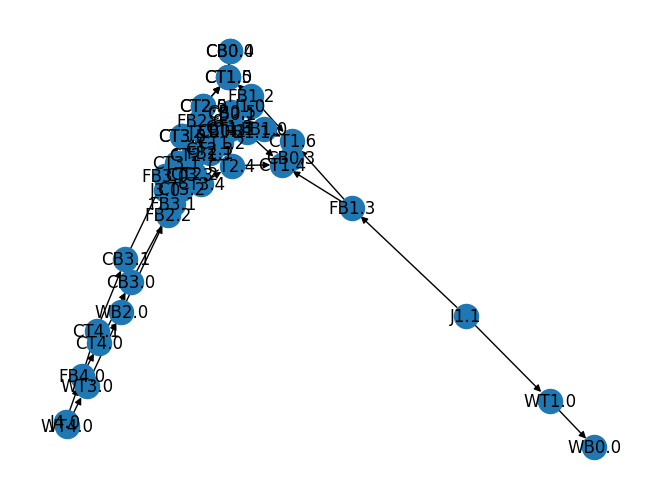

In [46]:
graph.plot_connectivity()

In [47]:
graph.nodes['WB2.0']['element']

Element(geometry=<POLYGON ((33.11 22.667, 33.11 33.024, 33.709 33.024, 33.709 22.667, 33.11 2...>, tag='WB2.0', rank=0, intersections_above=[], intersections_below=[Intersection(intersecting_region=<LINESTRING (33.404 33.024, 33.396 22.667)>, other_geometry=<LINESTRING (33.396 22.346, 33.404 33.473)>, other_tag='FB2.2', other_index=None, other_reaction_type='point', other_extents=None)], correspondents_above=[Correspondent(overlap_ratio=0.6063790268475162, other_geometry=<POLYGON ((33.273 22.711, 33.273 33.291, 33.638 33.291, 33.638 22.711, 33.27...>, other_tag='WT3.0', other_rank=2, other_reaction_type='linear', other_extents=(0.0640694935207065, 10.356901710936528, 0.0, 10.312099999999997))], correspondents_below=[], plane_id=2, element_type='transfer', subelements=None, trib_area=None, reaction_type='linear', kwargs=None, extent_polygon=None)

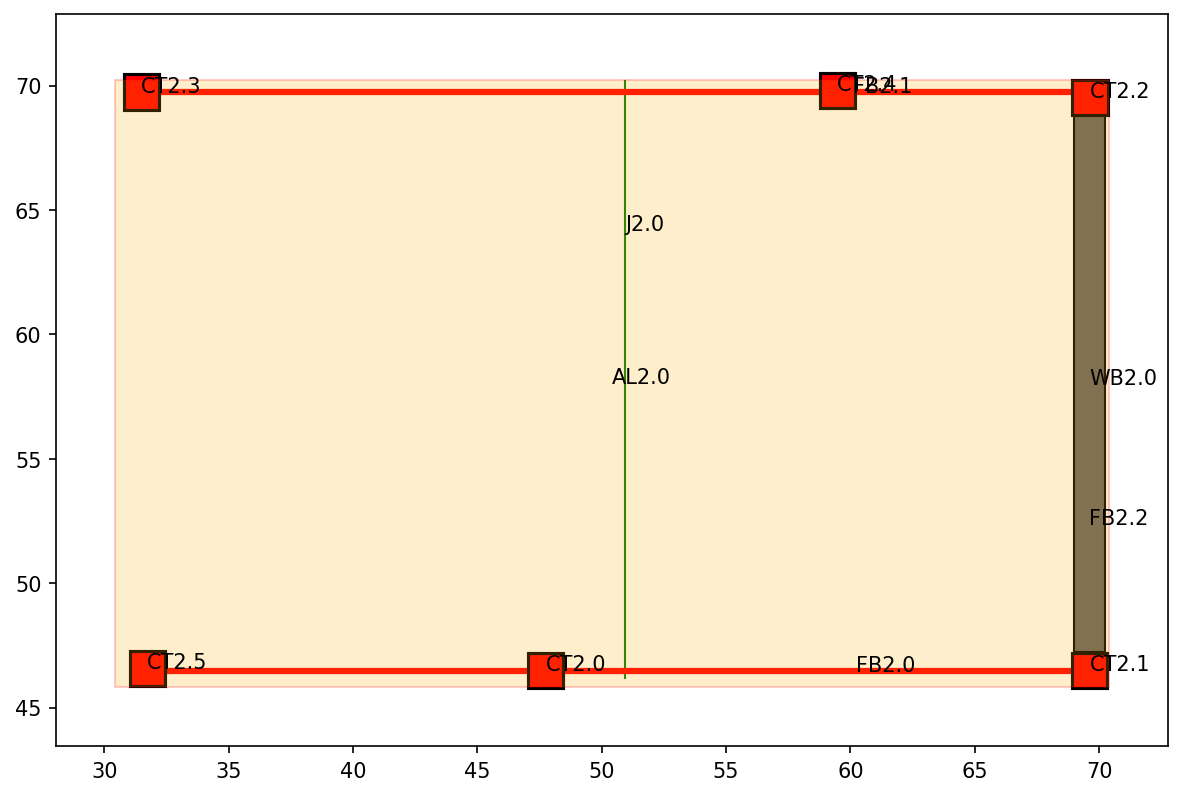

In [48]:
graph.plot_annotations(2)

In [49]:
# Note: The "Wall bottom" annotation transfers as a line load onto the FB2.2 beam and not onto the WT1.0 element on the page below
# The extent of the distributed load matches its location on the FB2.2 beam
les['FB2.2'].model()

ValueError: The .other_index attribute within the .intersections_above list is not calculated. Generate LoadedElement objects through the GeometryGraph interface in order to populate this necessary index.

In [ ]:
# The last elements on the page (the point loads) correctly display their transfers from above
les['CB0.4'].model

## 2. Output the model files

Currently outputs in either JSON or TOML. Both are equivalent to a dictionary and can be parsed by modules in the standard library, i.e. `toml`, `json`.

In [ ]:
import pathlib
output_dir = pathlib.Path("model_files")

file_format = "toml" # also try "json"

for loaded_element in les.values():
    if file_format == "toml":
        output_toml = output_dir / "toml"
        output_toml.mkdir(parents=True, exist_ok=True)
        with open(output_dir / "toml" / f"{loaded_element.tag}.toml", "wb") as file:
            loaded_element.dump_toml(file)
    elif file_format == "json":
        output_json = output_dir / "json"
        output_json.mkdir(parents=True, exist_ok=True)
        with open(output_dir / "json" / f"{loaded_element.tag}.json", "w") as file:
            loadeded_element.dump_json(file)
        